# House Price Prediction - Refactored Notebook

This notebook is organized step-by-step for learning and experimentation.


In [57]:
# =========================
# 1. IMPORTS
# =========================
# Import libraries for data handling, visualization, modeling, and evaluation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    XGBRegressor = None
    HAS_XGB = False


from sklearn.metrics import (
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.compose import TransformedTargetRegressor

# Cleaner chart defaults for notebook visuals
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [58]:
# =========================
# 2. LOAD DATA
# =========================
# Read the training data.
df = pd.read_csv("train.csv")

# Quick look at rows/columns
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

In [59]:
# =========================
# 3. DATA PREPROCESSING
# =========================
# Check missing values so we know what needs to be handled.
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print("Columns with missing values:", len(missing_summary))
missing_summary.head(15)

Columns with missing values: 19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
dtype: int64

In [60]:
# Fill missing values in numeric columns with median (simple and robust for beginners).
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Verify numeric columns have no missing values now
print("Remaining missing values in numeric columns:")
print(df[numeric_cols].isnull().sum().sum())

Remaining missing values in numeric columns:
0


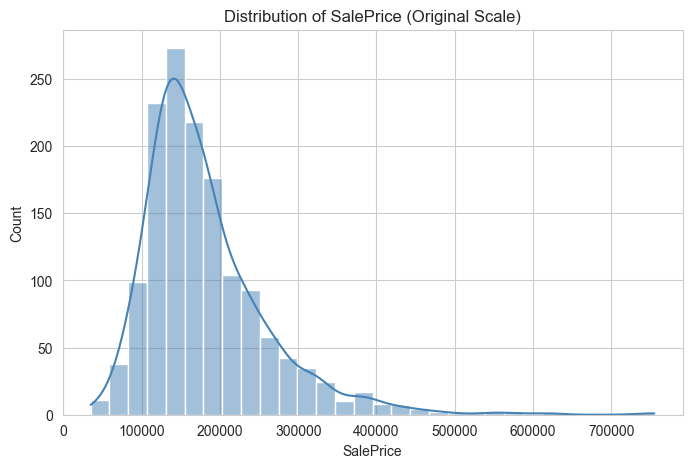

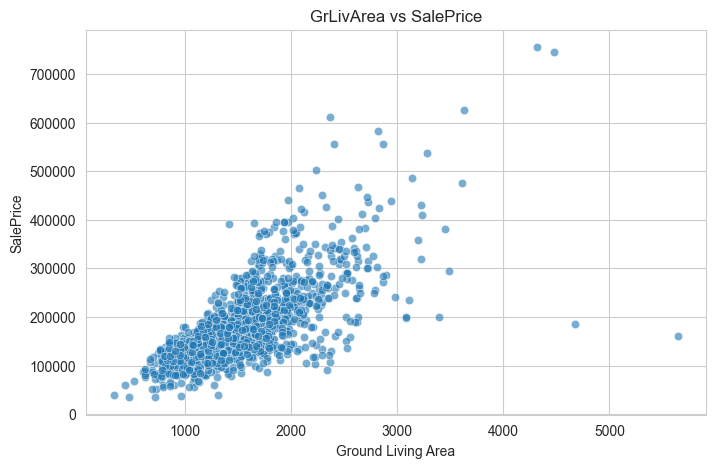

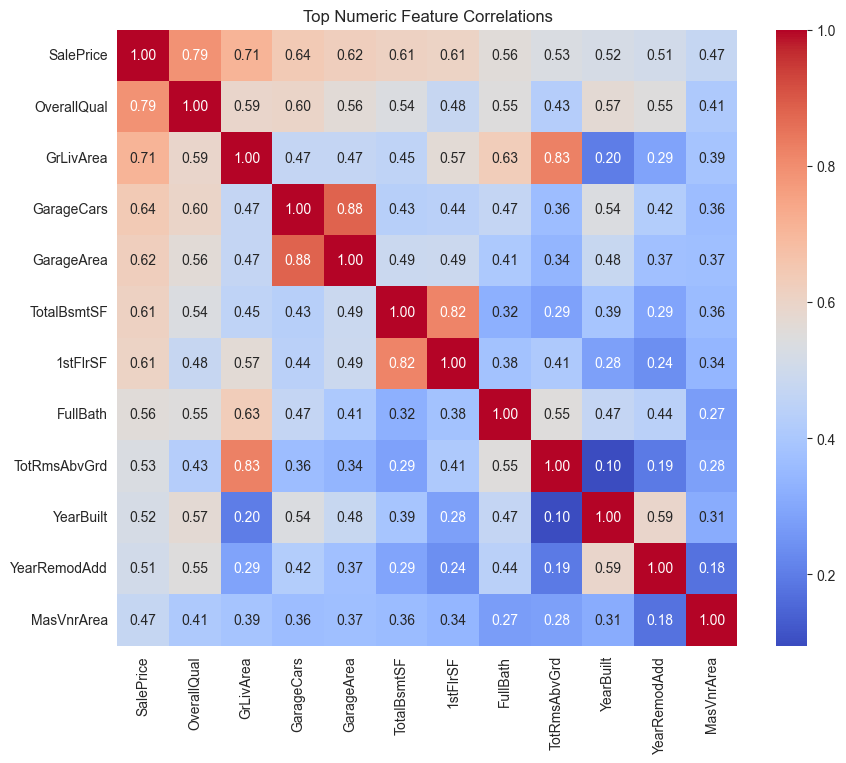

In [61]:
# =========================
# 4. EDA & VISUALIZATION
# =========================
# Original SalePrice distribution
plt.figure()
sns.histplot(df["SalePrice"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of SalePrice (Original Scale)")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

# Relationship: Living area vs SalePrice
plt.figure()
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.6)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Ground Living Area")
plt.ylabel("SalePrice")
plt.show()

# Correlation heatmap for top correlated numeric features
corr_to_target = (
    df.corr(numeric_only=True)["SalePrice"].abs().sort_values(ascending=False)
)
top_corr_features = corr_to_target.head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Numeric Feature Correlations")
plt.show()

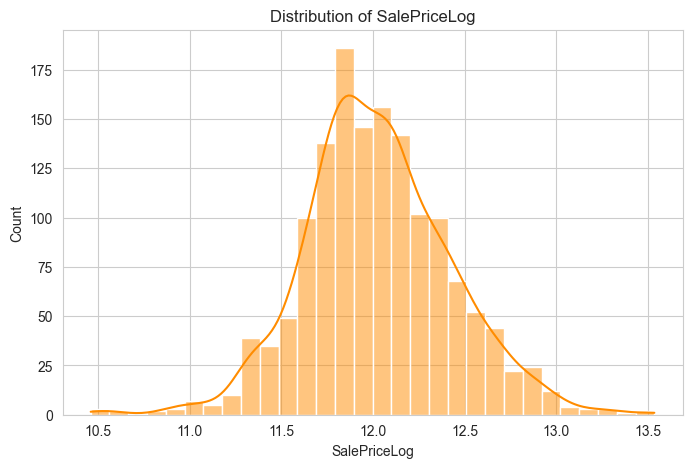

In [62]:
# =========================
# 5. FEATURE ENGINEERING
# =========================
# Keep log transformation in a NEW column (do not overwrite SalePrice).
df["SalePriceLog"] = np.log1p(df["SalePrice"])

# Simple feature engineering: total square footage from basement + 1st + 2nd floor.
# This captures overall usable area better than each one separately.
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

# Optional simple age feature
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# Visualize log target distribution (usually more normal-like)
plt.figure()
sns.histplot(df["SalePriceLog"], bins=30, kde=True, color="darkorange")
plt.title("Distribution of SalePriceLog")
plt.xlabel("SalePriceLog")
plt.ylabel("Count")
plt.show()

In [63]:
feature_df = df.select_dtypes(include=np.number).copy()

# Remove target columns and ID
for col in ["SalePrice", "SalePriceLog", "Id"]:
    if col in feature_df.columns:
        feature_df = feature_df.drop(columns=col)

# Correlation-based filtering
corr_matrix = feature_df.corrwith(df["SalePriceLog"])
top_features = corr_matrix[abs(corr_matrix) > 0.3].index

# print("Top features:", top_features)

X = feature_df[top_features]

y_log = df["SalePriceLog"]
y_actual = df["SalePrice"]

# Train-test split
X_train, X_test, y_train_log, y_test_log, y_train_actual, y_test_actual = (
    train_test_split(X, y_log, y_actual, test_size=0.2, random_state=42)
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 21)
Test shape: (292, 21)


In [64]:
from sklearn.inspection import permutation_importance
# Train multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=7)
}
if HAS_XGB:
    models['xgb'] = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
results = []

# -------------------------
# Safety checks + helpers
# -------------------------
# Reminder: model.predict() outputs SalePriceLog because we trained on log.
def check_log_target(model_name, y_candidate_log, y_reference_actual, tol_ratio=0.05):
    """Warn if expm1(y_candidate_log) doesn't match y_reference_actual."""
    inv = np.expm1(y_candidate_log)
    denom = np.median(np.abs(y_reference_actual)) + 1e-9
    ratio = np.median(np.abs(inv - y_reference_actual)) / denom
    ok = ratio <= tol_ratio
    if not ok:
        print(f"WARNING: {model_name} looks like it was fitted on the wrong target scale. ratio={ratio:.3g}")
    return ok

def check_inverse_transform(model_name, y_candidate_actual, y_reference_actual, min_ratio=0.2, max_ratio=5.0):
    """Warn if inverse-transformed predictions do not look like SalePrice scale."""
    if y_candidate_actual is None or not np.all(np.isfinite(y_candidate_actual)):
        print(f"WARNING: {model_name} predictions contain NaN/inf after inverse transform.")
        return False
    denom = np.median(np.abs(y_reference_actual)) + 1e-9
    ratio = np.median(np.abs(y_candidate_actual)) / denom
    ok = (min_ratio <= ratio <= max_ratio)
    if not ok:
        print(f"WARNING: {model_name} predictions may not be inverse transformed correctly. ratio={ratio:.3g}")
    return ok

model_safety = []





# feature_importance_results = {}

# for model_name, model in models.items():
#     # Fit model
#     fit_log_target_ok = check_log_target(model_name, y_train_log, y_train_actual)
#     model.fit(X_train, y_train_log)

#     # Predict
#     y_pred_log = model.predict(X_test)
#     y_pred = np.expm1(y_pred_log)

#     inverse_ok = check_inverse_transform(model_name, y_pred, y_test_actual)

#     # Metrics
#     mae = mean_absolute_error(y_test_actual, y_pred)
#     error_percent = (mae / y_test_actual.mean()) * 100

#     results.append({
#         'Model': model_name,
#         'MAE': mae,
#         'Error %': error_percent
#     })

#     model_safety.append({
#         'Model': model_name,
#         'fit_on_y_train_log_ok': bool(fit_log_target_ok),
#         'inverse_transform_ok': bool(inverse_ok),
#     })

from sklearn.inspection import permutation_importance

feature_importance_results = {}
selected_features_per_model = {}

for model_name, model in models.items():
    print(f"\n🚀 Training {model_name}...\n")

    # Fit model
    model.fit(X_train, y_train_log)

    # Predict
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # Metrics
    mae = mean_absolute_error(y_test_actual, y_pred)
    error_percent = (mae / y_test_actual.mean()) * 100

    results.append({
        'Model': model_name,
        'MAE': mae,
        'Error %': error_percent
    })

    # =========================
    # PERMUTATION IMPORTANCE
    # =========================
    perm_result = permutation_importance(
        model,
        X_test,
        y_test_log,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance = pd.Series(perm_result.importances_mean, index=X_test.columns)
    importance = importance.sort_values(ascending=False)

    feature_importance_results[model_name] = importance

    # 🔥 Select top features (you can change number)
    top_features = importance.head(15).index
    selected_features_per_model[model_name] = top_features

    print(f"🔥 {model_name} - Top Features:\n")
    print(top_features)

    # =========================
    # PERMUTATION IMPORTANCE
    # =========================
    result = permutation_importance(
        model,
        X_test,
        y_test_log,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance = pd.Series(result.importances_mean, index=X_test.columns)
    importance = importance.sort_values(ascending=False)

    feature_importance_results[model_name] = importance

    print(f"\n🔥 {model_name} - Top Features:\n")
    print(importance.head(10))
    final_results = []

for model_name, model in models.items():
    print(f"\n🎯 Retraining {model_name} with selected features...\n")

    # Get model-specific features
    selected_features = selected_features_per_model[model_name]

    # Filter dataset
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]

    # Train again
    model.fit(X_train_sel, y_train_log)

    # Predict
    y_pred_log = model.predict(X_test_sel)
    y_pred = np.expm1(y_pred_log)

    # Evaluate
    mae = mean_absolute_error(y_test_actual, y_pred)
    error_percent = (mae / y_test_actual.mean()) * 100

    final_results.append({
        'Model': model_name,
        'MAE': mae,
        'Error %': error_percent
    })

    print(f"{model_name} → MAE: {mae:.2f}, Error %: {error_percent:.2f}")


🚀 Training Linear Regression...

🔥 Linear Regression - Top Features:

Index(['OverallQual', 'GrLivArea', 'HouseAge', 'YearRemodAdd', 'GarageCars',
       'Fireplaces', 'BsmtFinSF1', 'TotRmsAbvGrd', 'TotalBsmtSF', 'GarageArea',
       'WoodDeckSF', 'TotalSF', 'GarageYrBlt', 'FullBath', 'HalfBath'],
      dtype='object')

🔥 Linear Regression - Top Features:

OverallQual     0.230020
GrLivArea       0.095389
HouseAge        0.070918
YearRemodAdd    0.039871
GarageCars      0.032132
Fireplaces      0.024407
BsmtFinSF1      0.021462
TotRmsAbvGrd    0.015391
TotalBsmtSF     0.009592
GarageArea      0.008894
dtype: float64

🚀 Training Decision Tree...

🔥 Decision Tree - Top Features:

Index(['TotalSF', 'OverallQual', 'GarageArea', 'YearBuilt', 'GarageCars',
       'YearRemodAdd', 'BsmtFinSF1', 'GarageYrBlt', 'TotalBsmtSF',
       'Fireplaces', 'GrLivArea', '2ndFlrSF', 'HouseAge', 'LotFrontage',
       'OpenPorchSF'],
      dtype='object')

🔥 Decision Tree - Top Features:

TotalSF         0.3

In [65]:
# =========================
# 7. MODEL COMPARISON
# =========================
# Create a clean comparison table (lower MAE and Error % are better).
comparison_df = pd.DataFrame(final_results).sort_values(by="MAE").reset_index(drop=True)
comparison_df

,Model,MAE,Error %
0,Random Forest,18816.321835,10.521327
1,xgb,19203.582031,10.737868
2,Linear Regression,20054.470095,11.213650
3,Decision Tree,24652.900685,13.784906
4,KNN,25046.247255,14.004850


In [66]:
# =========================
# 8. CROSS VALIDATION
# =========================
# 5-fold cross-validation using TransformedTargetRegressor so log transform is used properly.
cv = KFold(n_splits=6, shuffle=True, random_state=42)
cv_rows = []

for model_name, model in models.items():
    reg = TransformedTargetRegressor(
        regressor=model, func=np.log1p, inverse_func=np.expm1
    )

    # MAE is computed on original SalePrice scale
    cv_scores = cross_val_score(
        reg, X, y_actual, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1
    )

    cv_mae = -cv_scores
    cv_rows.append(
        {"Model": model_name, "CV MAE Mean": cv_mae.mean(), "CV MAE Std": cv_mae.std()}
    )

cv_results_df = (
    pd.DataFrame(cv_rows).sort_values(by="CV MAE Mean").reset_index(drop=True)
)
cv_results_df

,Model,CV MAE Mean,CV MAE Std
0,xgb,18418.861816,1319.448405
1,Random Forest,18607.689825,1599.037291
2,Linear Regression,20868.344290,3929.632093
3,KNN,25518.494248,1790.965048
4,Decision Tree,27257.823819,1892.342202


In [67]:
# =========================
# 9. RESULTS & INSIGHTS
# =========================
# Final merged view of holdout and cross-validation performance.
final_results = comparison_df.merge(cv_results_df, on="Model", how="left")
final_results

,Model,MAE,Error %,CV MAE Mean,CV MAE Std
0,Random Forest,18816.321835,10.521327,18607.689825,1599.037291
1,xgb,19203.582031,10.737868,18418.861816,1319.448405
2,Linear Regression,20054.470095,11.213650,20868.344290,3929.632093
3,Decision Tree,24652.900685,13.784906,27257.823819,1892.342202
4,KNN,25046.247255,14.004850,25518.494248,1790.965048


In [68]:
# Quick beginner-friendly interpretation
best_holdout_model = comparison_df.iloc[0]
best_cv_model = cv_results_df.iloc[0]

print(f"Best model on test split (lowest MAE): {best_holdout_model['Model']}")
print(f"Test MAE: {best_holdout_model['MAE']:.2f}")
print(f"Test Error %: {best_holdout_model['Error %']:.2f}%")
print("-" * 50)
print(f"Best model by 5-fold CV MAE: {best_cv_model['Model']}")
print(f"CV MAE Mean: {best_cv_model['CV MAE Mean']:.2f}")
print(f"CV MAE Std: {best_cv_model['CV MAE Std']:.2f}")

# Select a single model for ALL following evaluation plots
best_model_name = best_holdout_model["Model"]
best_model = models[best_model_name]

# Predictions: first in log-space, then inverse-transform to actual SalePrice
selected_features = selected_features_per_model.get(best_model_name, X_test.columns)
y_pred_log = best_model.predict(X_test[selected_features])
y_pred = np.expm1(y_pred_log)

y_pred_train_log = best_model.predict(X_train[selected_features])
y_pred_train = np.expm1(y_pred_train_log)

# Optional alias (older cells used y_pred_actual)
y_pred_actual = y_pred
y_pred_train_actual = y_pred_train

_ = check_inverse_transform(best_model_name, y_pred, y_test_actual)
print("-" * 50)
print(f"Selected model for evaluation (holdout best): {best_model_name}")

Best model on test split (lowest MAE): Random Forest
Test MAE: 18816.32
Test Error %: 10.52%
--------------------------------------------------
Best model by 5-fold CV MAE: xgb
CV MAE Mean: 18418.86
CV MAE Std: 1319.45
--------------------------------------------------
Selected model for evaluation (holdout best): Random Forest


In [69]:
# =========================
# 10. EVALUATION
# =========================
from sklearn.metrics import mean_squared_error, r2_score

print(
    "RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred))
)  # y_test_actual vs inverse-transformed predictions
print(
    "R2 Score:", r2_score(y_test_actual, y_pred)
)  # Model prediction vs actual variance

RMSE: 31096.862238555666
R2 Score: 0.8739278076364454


In [70]:
# Convert price into categories
# Binning of data
# pd.cut() (Fixed Binning)
# qcut = Quantile-based binning

# It divides your data into equal-sized groups (by count), not equal ranges.

# 2. q=3

# Split data into 3 equal parts (tertiles):
# Lowest 33% → "Low"
# Middle 33% → "Medium"
# Highest 33% → "High"

# 3. Labels
# Assigns meaningful names instead of numbers.
df["PriceCategory"] = pd.qcut(df["SalePrice"], q=3, labels=["Low", "Medium", "High"])
print(df["PriceCategory"])


# bins = [0, 150000, 300000, 1000000]#Fixed bins (manual ranges)#data becomes skewed
# | Category | Count |
# | -------- | ----- |
# | Low      | 50    |
# | Medium   | 180   |
# | High     | 30    |

# Quantile bins (data-driven)
bins = df["SalePrice"].quantile([0, 0.33, 0.66, 1]).values
# | Category | Count |
# | -------- | ----- |
# | Low      | ~97   |
# | Medium   | ~97   |
# | High     | ~97   |

labels = ["Low", "Medium", "High"]

y_test_cls = pd.cut(y_test_actual, bins=bins, labels=labels)
y_pred_cls = pd.cut(y_pred, bins=bins, labels=labels)

0         High
1       Medium
2         High
3       Medium
4         High
         ...  
1455    Medium
1456      High
1457      High
1458    Medium
1459    Medium
Name: PriceCategory, Length: 1460, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


In [71]:
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("Precision:", precision_score(y_test_cls, y_pred_cls, average="weighted"))
print("Recall:", recall_score(y_test_cls, y_pred_cls, average="weighted"))
print("F1:", f1_score(y_test_cls, y_pred_cls, average="weighted"))

Accuracy: 0.8527397260273972
Precision: 0.8557121743542232
Recall: 0.8527397260273972
F1: 0.8539445117692822


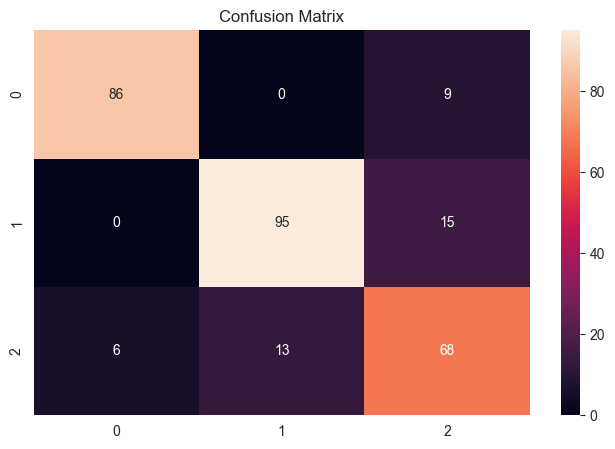

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_cls, y_pred_cls)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# Accuracy: 0.8732876712328768
# accuracy
# 20 + 127 + 108 = 255
# 20+0+4 + 0+127+12 + 7+14+108 = 292
# 255 / 292 ≈ 87.3%
# Correct

In [73]:
from sklearn.metrics import r2_score

# R2 on ACTUAL scale only (after inverse-transform)
train_r2_actual = r2_score(y_train_actual, y_pred_train)
test_r2_actual = r2_score(y_test_actual, y_pred)

print(train_r2_actual, test_r2_actual)

print("\n--- Target-variable pipeline summary ---")
print("Models evaluated (holdout MAE):", comparison_df["Model"].tolist())

print("Safety checks (fit target + inverse transform):")
for row in model_safety:
    print(
        f"  - {row['Model']}: fit_on_y_train_log_ok={row['fit_on_y_train_log_ok']}, inverse_transform_ok={row['inverse_transform_ok']}"
    )

print("Inconsistencies fixed:")
print(
    "  - Train/Test R2 is now computed on actual SalePrice (after expm1), not on SalePriceLog."
)
print(
    "  - RMSE/confusion-matrix/classification now use predictions from the selected best holdout model (y_pred), not leftover last-loop predictions."
)

# | Case              | Meaning        |
# | ----------------- | -------------- |
# | Train >> Test     | Overfitting ❌  |
# | Both low          | Underfitting ❌ |
# | Both similar high | Good ✅         |


# 🟢 Train = 0.999
# Almost perfect fit
# Model learned training data extremely well
# 🟡 Test = 0.885
# Very strong performance
# Generalizing well to unseen data
# Good model with slight overfitting ⚠️ (but acceptable)

0.9774698917093121 0.8739278076364454

--- Target-variable pipeline summary ---
Models evaluated (holdout MAE): ['Random Forest', 'xgb', 'Linear Regression', 'Decision Tree', 'KNN']
Safety checks (fit target + inverse transform):
Inconsistencies fixed:
  - Train/Test R2 is now computed on actual SalePrice (after expm1), not on SalePriceLog.
  - RMSE/confusion-matrix/classification now use predictions from the selected best holdout model (y_pred), not leftover last-loop predictions.


In [74]:
# | Model             | Type          |
# | ----------------- | ------------- |
# | Linear Regression | High bias     |
# | Decision Tree     | High variance |
# | XGBoost           | Balanced ✅    |

In [75]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# max_depth: How deep each tree should be
# learning_rate: How fast model learns
# n_estimators: Number of trees

# It creates all combinations of parameters:
# max_depth	learning_rate	n_estimators
# 3	0.01	200
# 3	0.01	500
# 3	0.05	200
# ...	...	...
# 👉 Total = 3 × 2 × 2 = 12 combinations

# For each combination:
# It trains the model
# Uses Cross Validation (cv=3)
# → splits data into 3 parts and tests multiple times

# It evaluates performance using:

params = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [200, 500],
}

from sklearn.metrics import mean_absolute_error, make_scorer


# GridSearchCV scoring is done on the ACTUAL SalePrice scale.
# We invert both y_true and y_pred from log-space using expm1.
def mae_actual_from_log(y_true_log, y_pred_log):
    y_true_actual = np.expm1(y_true_log)
    y_pred_actual = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_actual, y_pred_actual)


scorer = make_scorer(mae_actual_from_log, greater_is_better=False)

grid = GridSearchCV(XGBRegressor(), param_grid=params, cv=3, scoring=scorer)
# 12 combinations × 3 folds = 36 model trainings 🤯

grid.fit(X_train, y_train_log)
# print(grid.best_params_)
# ✅ Out of all 12 combinations, this set gave the best performance
# {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


# Without tuning:
# “I picked random settings and hoped it works”
# With tuning:
# “I tested multiple configurations and selected the best scientifically”

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], 'n_estimators': [200, 500]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [ ]:
# from sklearn.model_selection import GridSearchCV

# pipeline = Pipeline([
#     ("prep", preprocessor),
#     ("model", XGBRegressor())  # placeholder
# ])

# param_grid = [
#     {"model": [LinearRegression()]},
#     {"model": [RandomForestRegressor()], "model__n_estimators": [100, 200]},
#     {"model": [XGBRegressor()], "model__n_estimators": [200, 500]}
# ]
# grid = GridSearchCV(pipeline, param_grid, cv=3)